In this notebook I am going to figure out how to mask the vectors that appear to be part of a stream, as seen in Band 5. I want to mask then, rotate them 90 degrees, separate them from the ones I will try to fit for, and plot them a different colour. 

In [1]:
%run "/Users/audreyburggraf/Desktop/QUEEN'S/THESIS RESEARCH/PLOTTING C29 989/FUNCTIONS/load_functions"

/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.2' currently installed).
  from pandas.core import (


fortran mie routines unavailable


/opt/anaconda3/lib/python3.9/site-packages/dsharp_opac/dsharp_opac.py:47: UserWarning: could not import compiled mie code - mie calculation will be slow
  warnings.warn(


In [2]:
%run constants.py

In [9]:
generate_polarization_vectors_band47

<function IntroductionFunctions.generate_polarization_vectors_band47(ny, nx, RA_centre_pix, Dec_centre_pix, uniform_angle, StokesI_mJy, POLI_mJy, POLI_err_mJy, PA_real_sky_rad, PA_err_deg, band, step=None, vector_len_pix=None)>

In [7]:
# Use the variable from constants.py
band5_data_folder_path = constants.band5_data_folder_path
functions_folder_path = constants.functions_folder_path


# Define file paths
StokesI_file = band5_data_folder_path + "IRS63_BAND5_StokesI_clean_nopbcorr_p4.fits"
StokesQ_file = band5_data_folder_path + "IRS63_BAND5_StokesQ_clean_nopbcorr_p4.fits"
StokesU_file = band5_data_folder_path + "IRS63_BAND5_StokesU_clean_nopbcorr_p4.fits"


# Stokes I
# -------------------------------------------------------------------------------------------------------
StokesI_header, _, StokesI_Jy, StokesI_wcs = read_in_file(StokesI_file)
StokesI_mJy = convert_jy_to_mjy(StokesI_Jy)

# Stretch the Stokes I data and get the cbar ticks
StokesI_stretched_mJy, StokesI_unstretched_cbar_ticks = normalize_stokesI_for_cmap(StokesI_mJy)

nx, ny = StokesI_mJy.shape
# -------------------------------------------------------------------------------------------------------
# Stokes I error
# -------------------------------------------------------------------------------------------------------
StokesI_err_mJy = np.full((ny, nx), constants.StokesI_err_mJy_band5)
# -------------------------------------------------------------------------------------------------------


# Stokes Q
# -------------------------------------------------------------------------------------------------------
_, _, StokesQ_Jy, _ = read_in_file(StokesQ_file)
StokesQ_mJy = convert_jy_to_mjy(StokesQ_Jy)
# -------------------------------------------------------------------------------------------------------
# Stokes Q Error
# -------------------------------------------------------------------------------------------------------
StokesQ_err_mJy = np.full((ny, nx), constants.StokesQ_err_mJy_band5)
# -------------------------------------------------------------------------------------------------------


# Stokes U
# -------------------------------------------------------------------------------------------------------
_, _, StokesU_Jy, _ = read_in_file(StokesU_file)
StokesU_mJy = convert_jy_to_mjy(StokesU_Jy)
# -------------------------------------------------------------------------------------------------------
# Stokes U Error
# -------------------------------------------------------------------------------------------------------
StokesU_err_mJy = np.full((ny, nx), constants.StokesQ_err_mJy_band5)
# -------------------------------------------------------------------------------------------------------


# Polarization Intensity
# -------------------------------------------------------------------------------------------------------
POLI_calc = calculate_polarized_intensity(StokesQ_mJy, StokesU_mJy)
POLI_mJy = POLI_calc

# # Ensure POLI_mJy is shaped (ny, nx)
# POLI_mJy_resized = POLI_mJy[:ny, :nx]



# Save data
# hdu = fits.PrimaryHDU(data=POLI_mJy, header=StokesI_header)
# hdu.writeto(band5_data_folder_path + "POLI_mJy_calculated_BAND5.fits", overwrite=True)

# _, _, POLI_Jy, _ = read_in_file(POLI_file)
# POLI_mJy = convert_jy_to_mjy(POLI_Jy)
# -------------------------------------------------------------------------------------------------------
# Polarization Intensity error
# -------------------------------------------------------------------------------------------------------
POLI_err_mJy = calculate_polarized_intensity_err(StokesQ_mJy, StokesU_mJy, StokesQ_err_mJy, StokesU_err_mJy)
# -------------------------------------------------------------------------------------------------------



# Polarization Angle
# -------------------------------------------------------------------------------------------------------
PA_calc_rad = calculate_polarization_angle(StokesQ_Jy, StokesU_Jy)
PA_rad = PA_calc_rad 
# -------------------------------------------------------------------------------------------------------
# Polarization Angle error
# -------------------------------------------------------------------------------------------------------
PA_err_rad = calculate_polarization_angle_error(StokesQ_mJy, StokesU_mJy, 
                                                StokesQ_err_mJy, StokesU_err_mJy)

PA_err_deg = np.degrees(PA_err_rad)
# -------------------------------------------------------------------------------------------------------


# Polarized Fraction
# -------------------------------------------------------------------------------------------------------
POLF = calculate_polarized_fraction(StokesQ_mJy, StokesU_mJy, StokesI_mJy)
# -------------------------------------------------------------------------------------------------------
# Polarized Fraction Error
# -------------------------------------------------------------------------------------------------------
POLF_err = calculate_polarized_fraction_err(StokesQ_mJy, StokesU_mJy, StokesI_mJy, 
                                            StokesQ_err_mJy, StokesU_err_mJy, StokesI_err_mJy)
# -------------------------------------------------------------------------------------------------------



BMAJ_deg, BMIN_deg, BMAJ_pix, BMIN_pix, BPA_deg_cartesian, reference_length_pix, RA_centre_pix, Dec_centre_pix, xmin, xmax, ymin, ymax = get_plotting_parameters(StokesI_header, StokesI_wcs, 7)




# Find the vectors
# -------------------------------------------------------------------------------------------------------
# in the file:MakingGridFunctions.py make_vectors_band47
results = generate_polarization_vectors_band47(ny, nx,
                                               RA_centre_pix, Dec_centre_pix,
                                               constants.minor_angle_rad_sky_band5,
                                               StokesI_mJy, 
                                               POLI_mJy, POLI_err_mJy,
                                               PA_rad, PA_err_deg,
                                               'band 5')
# -------------------------------------------------------------------------------------------------------




# Accessing the actual vector data and anglesf
vector_data_actual_cartesian_wstream = results['vector_data_actual_cartesian']
vector_angle_actual_sky_wstream = results['vector_angle_actual_sky']

vector_data_100Uniform_cartesian = results['vector_data_100Uniform_cartesian']
vector_angle_100Uniform_sky = results['vector_angle_100Uniform_sky']

vector_data_100Azimuthal_cartesian = results['vector_data_100Azimuthal_cartesian']
vector_angle_100Azimuthal_sky      = results['vector_angle_100Azimuthal_sky']

StokesQ_grid_100Uniform  = results['StokesQ_grid_100Uniform']
StokesU_grid_100Uniform  = results['StokesU_grid_100Uniform']

StokesQ_grid_100Azimuthal = results['StokesQ_grid_100Azimuthal']
StokesU_grid_100Azimuthal = results['StokesU_grid_100Azimuthal']
# -------------------------------------------------------------------------------------------------------


# separate the data from the stream
# -------------------------------------------------------------------------------------------------------
stream_vectors = []
vector_data_actual_cartesian = []

stream_xmin = 540
stream_xmax = 580
stream_ymin = 490
stream_ymax = 540

for row in vector_data_actual_cartesian_wstream:
    x0, x1, y0, y1 = row

    if (stream_xmin <= x0 <= stream_xmax and stream_xmin <= x1 <= stream_xmax and
        stream_ymin <= y0 <= stream_ymax and stream_ymin <= y1 <= stream_ymax):
        stream_vectors.append(row)
    else:
        vector_data_actual_cartesian.append(row)
# -------------------------------------------------------------------------------------------------------

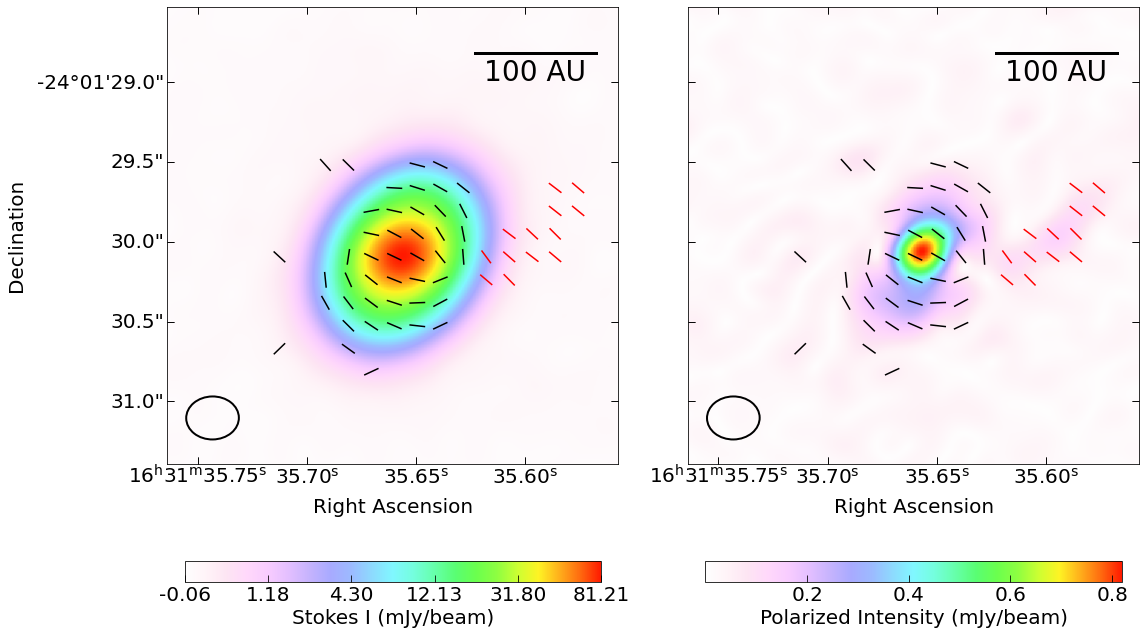

In [8]:
fig, ax = create_stokes_i_plus_one_base_plot(StokesI_wcs, StokesI_stretched_mJy, 
                                             normalized_cbar_ticks, StokesI_unstretched_cbar_ticks, 
                                             POLI_mJy, 'Polarized Intensity (mJy/beam)',
                                             soft_colormap_v2, 
                                             xmin - 10, xmax + 10, 
                                             ymin - 10, ymax + 10, 
                                             reference_length_pix, reference_length_AU,
                                             BMAJ_pix, BMIN_pix, BPA_deg_cartesian, 
                                             max_length_pix, reference_fraction)


for i in range(2):
    for row in vector_data_actual_cartesian:
        ax[i].plot([row[0], row[1]], [row[2], row[3]], color='black')
    
    for row in stream_vectors:
        ax[i].plot([row[0], row[1]], [row[2], row[3]], color='red')